# Parte I: Conceptos de Machine Learning

## 1. Diferencia entre aprendizaje supervisado y no supervisado

El **aprendizaje supervisado** es un tipo de Machine Learning en el que el modelo se entrena utilizando datos que ya contienen una **respuesta conocida**. Es decir, cada registro incluye variables de entrada y también una variable objetivo que el modelo debe aprender a predecir. Su finalidad principal es encontrar patrones que permitan hacer predicciones sobre datos nuevos.

Por otro lado, el **aprendizaje no supervisado** trabaja con datos que **no tienen una respuesta o etiqueta definida**. En este caso, el objetivo no es predecir una variable concreta, sino descubrir estructuras, relaciones o agrupaciones ocultas dentro de los datos.

En resumen:

- **Aprendizaje supervisado**: aprende a predecir una respuesta conocida.
- **Aprendizaje no supervisado**: busca patrones o grupos sin una respuesta previa.

---

## 2. Predicción de enfermedad: ¿qué tipo de aprendizaje corresponde?

En el caso de querer construir un programa que, a partir de ciertos datos de una persona, determine si está **enferma o no enferma**, corresponde utilizar un modelo de **aprendizaje supervisado**.

Esto se debe a que la variable que se quiere predecir ya está definida previamente, en este caso con dos posibles categorías:

- Enfermo
- No enfermo

Como la salida esperada pertenece a categorías, este problema corresponde específicamente a una tarea de **clasificación** dentro del aprendizaje supervisado.

---

## 3. ¿Por qué se divide la data en dos sets?

La división de los datos en dos conjuntos permite evaluar si el modelo realmente aprendió patrones útiles o si simplemente memorizó los datos originales.

### a) Conjunto de entrenamiento (*training set*)

Este conjunto se utiliza para **entrenar el modelo**, es decir, para que el algoritmo identifique relaciones entre las variables de entrada y la variable objetivo.

### b) Conjunto de prueba (*test set*)

Este conjunto se utiliza para **evaluar el rendimiento del modelo** con datos que no vio durante el entrenamiento. De esta forma, se puede medir qué tan bien generaliza frente a casos nuevos.

Esta separación es fundamental, ya que un modelo puede obtener muy buenos resultados con los datos con los que fue entrenado, pero fallar al enfrentarse a datos reales. En palabras simples: hay modelos que parecen genios, y fallar al momento de enfrentarse a casos reales.

---

## 4. Diferencia entre regresión lineal en estadística y en Machine Learning

La **regresión lineal en estadística** y la **regresión lineal en Machine Learning** comparten la misma base matemática, pero tienen enfoques distintos.

### Enfoque estadístico
Desde la estadística, la regresión lineal se utiliza principalmente para **explicar la relación entre variables**. Aquí interesa entender cómo influye cada variable independiente sobre la variable dependiente, interpretar coeficientes y analizar supuestos del modelo.

### Enfoque de Machine Learning
Desde Machine Learning, la regresión lineal se usa principalmente para **predecir valores futuros o desconocidos**. En este enfoque, la prioridad suele estar en el rendimiento predictivo del modelo más que en la interpretación profunda de cada coeficiente.

### Diferencia principal
- **Estadística**: se enfoca en la explicación e interpretación.
- **Machine Learning**: se enfoca en la predicción y el desempeño del modelo.

---

## 5. Aplicaciones de Machine Learning en la industria del retail automotriz

Para esta actividad se utilizará como ejemplo una empresa del rubro **retail dedicada a la venta de accesorios y repuestos para autos**, como Autoplanet.

### a) Aprendizaje supervisado: Clasificación

Una aplicación de clasificación en este tipo de empresa podría ser **predecir si un cliente comprará o no un producto complementario**.

Por ejemplo, si un cliente compra aceite para motor, el modelo podría predecir si también comprará un filtro de aceite, líquido refrigerante o un limpiador de inyectores. Esto permitiría mejorar estrategias de venta cruzada y recomendaciones en tienda.

### b) Aprendizaje supervisado: Regresión

Una aplicación de regresión podría ser **predecir el monto de ventas de una categoría de productos** en un período determinado.

Por ejemplo, el modelo podría estimar cuánto venderá una sucursal en baterías, plumillas o ampolletas durante la próxima semana, considerando variables como estacionalidad, promociones, clima o flujo de clientes.

### c) Aprendizaje no supervisado: Clustering

Una aplicación de clustering sería **segmentar clientes según sus hábitos de compra**.

Por ejemplo, se podrían identificar grupos como:

- Clientes que compran productos básicos de mantención
- Clientes que compran repuestos por fallas urgentes
- Clientes interesados en estética o accesorios
- Clientes frecuentes que compran para más de un vehículo

Esto ayudaría a personalizar promociones, mejorar el stock y entender mejor el comportamiento de compra.

### d) Aprendizaje no supervisado: Reducción de dimensionalidad

La reducción de dimensionalidad podría utilizarse para **simplificar grandes volúmenes de información sobre clientes, productos o ventas**, conservando la mayor parte de la información relevante.

Por ejemplo, si la empresa tiene muchas variables sobre comportamiento de compra, frecuencia de visitas, tipo de vehículo, categorías compradas y ticket promedio, esta técnica permitiría resumir esa información en menos dimensiones para facilitar análisis, visualizaciones y toma de decisiones.

# Parte 2: Analizando el Dataframe.

Primero, Importamos las librerias que utilizaremos en este analisis con python.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


Cargamos los datos del archivo que utilizaremos en este analisis

In [5]:
df = pd.read_excel("data-housing.xlsx") ## el archivo esta en excel, es importante darse cuenta de esto para leerlo.

## Analisis exploratorio de los datos.

In [8]:
df.info() ## analisis exploratorio de las columnas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   price            545 non-null    int64 
 1   area             545 non-null    int64 
 2   bedrooms         545 non-null    int64 
 3   bathrooms        545 non-null    int64 
 4   stories          545 non-null    int64 
 5   guestroom        545 non-null    object
 6   hotwaterheating  545 non-null    object
 7   airconditioning  545 non-null    object
 8   parking          545 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 38.4+ KB


In [9]:
df.head()

,price,area,bedrooms,bathrooms,stories,guestroom,hotwaterheating,airconditioning,parking
0,13300000,7420,4,2,3,no,no,yes,2
1,12250000,8960,4,4,4,no,no,yes,3
2,12250000,9960,3,2,2,no,no,no,2
3,12215000,7500,4,2,2,no,no,yes,3
4,11410000,7420,4,1,2,yes,no,yes,2


In [11]:
df.shape

(545, 9)

In [12]:
df.isnull().sum() ## revisamos si existen valores nulos

price              0
area               0
bedrooms           0
bathrooms          0
stories            0
guestroom          0
hotwaterheating    0
airconditioning    0
parking            0
dtype: int64

In [13]:
df.describe() ## un vistazo a la estadistica descriptiva

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## Variables categoricas (cuantos si y cuantos no)

In [15]:
df['guestroom'].value_counts()

guestroom
no     448
yes     97
Name: count, dtype: int64

In [16]:
df['hotwaterheating'].value_counts()


hotwaterheating
no     520
yes     25
Name: count, dtype: int64

In [17]:
df['airconditioning'].value_counts()

airconditioning
no     373
yes    172
Name: count, dtype: int64

In [33]:
df_corr = df.copy()

columnas_binarias = ['guestroom', 'hotwaterheating', 'airconditioning']

for col in columnas_binarias:
    df_corr[col] = df_corr[col].map({'yes': 1, 'no': 0})

df_corr.corr() 
corr = df_corr.corr()
## con el codigo anterior cambiamos las variables categoricas en numericas
## de esta forma al momento de correlacionar las variables podemos las variables utilizarlas categoricas en el analisis.

Creamos grafico de correlacion de las variables.

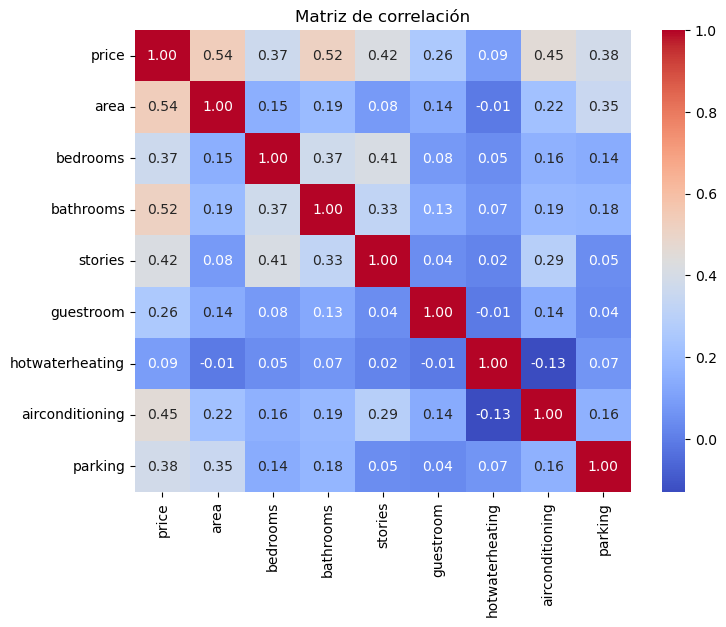

In [29]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de correlación')
plt.show()

## Buscamos valores atipicos.

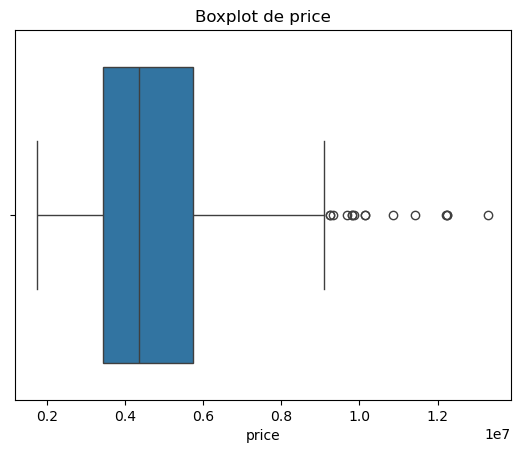

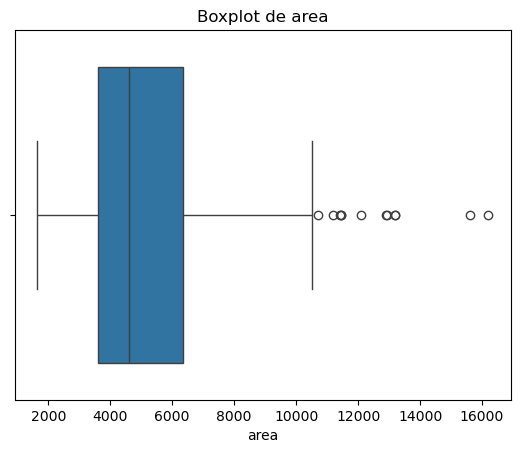

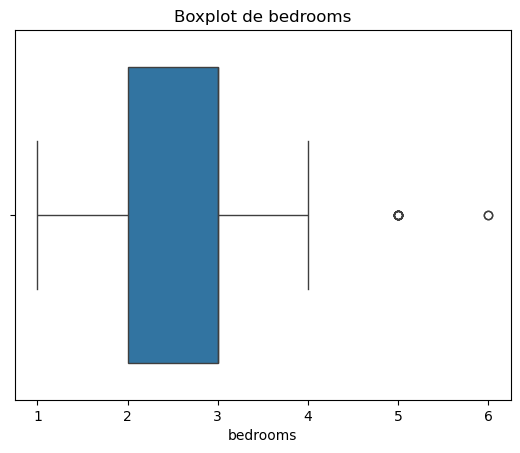

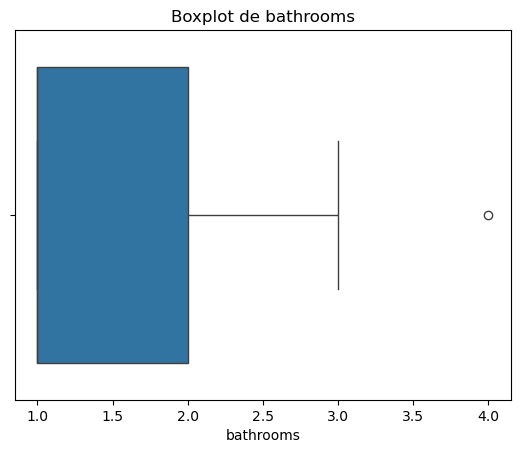

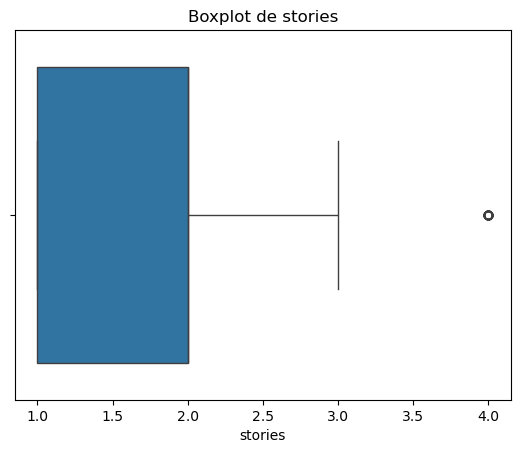

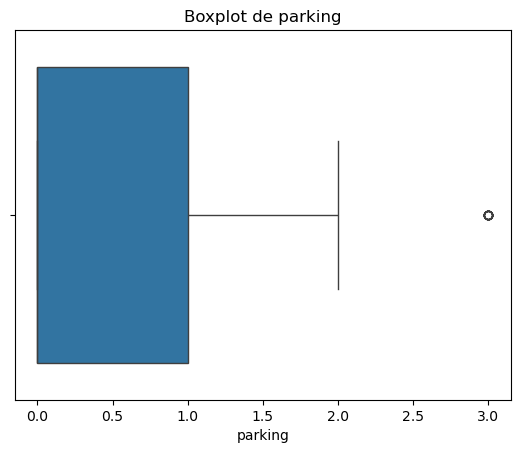

In [32]:
numericas = df.select_dtypes(include=['number']).columns

for col in numericas:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
    plt.show()

In [31]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['price'] < Q1 - 1.5*IQR) | (df['price'] > Q3 + 1.5*IQR)]

print("Cantidad de outliers en price:", len(outliers))

Cantidad de outliers en price: 15


## Análisis de valores atípicos

Se utilizaron diagramas de caja (boxplots) para analizar la presencia de valores atípicos en todas las variables numéricas.

Adicionalmente, se aplicó el método del rango intercuartílico (IQR) sobre la variable `price`, al ser la variable objetivo del modelo. Esto permitió cuantificar la cantidad de valores atípicos presentes, identificándose un total de 15 observaciones fuera del rango esperado.

Este enfoque permite complementar el análisis visual con una medida cuantitativa sobre la variable más relevante del estudio.

# Entrenamiento del modelo

In [34]:
# Variable objetivo
y = df_corr['price']

# Variables predictoras
X = df_corr.drop('price', axis=1)

In [35]:
## dividimos los datos en 80/20, 80% de entrenamiento y 20% de testeo
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [36]:
## creamos el modelo con los datos entrenados
modelo = LinearRegression()
modelo.fit(X_train, y_train)

LinearRegression()

revisamos si el modelo esta funcionando correctamente:

In [37]:
modelo.coef_

array([2.67674095e+02, 1.23387337e+05, 1.09893645e+06, 3.59272293e+05,
       5.81768639e+05, 6.63421096e+05, 8.81775436e+05, 2.82934838e+05])

In [38]:
modelo.intercept_

np.float64(327662.9336349908)

el modelo nos esta devolviendo el coeficiente y el intercepto de manera correcta, sin errores, por lo que el modelo se encuentra en funcionamiento.

## Probamos el modelo creado con predicciones.

In [39]:
y_train_pred = modelo.predict(X_train)

mse_train = mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

print("MSE entrenamiento:", mse_train)
print("R2 entrenamiento:", r2_train)

MSE entrenamiento: 1142290980321.328
R2 entrenamiento: 0.6295343438678265


In [40]:
y_test_pred = modelo.predict(X_test)

mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print("MSE prueba:", mse_test)
print("R2 prueba:", r2_test)

MSE prueba: 1961490677565.488
R2 prueba: 0.6119372009958433


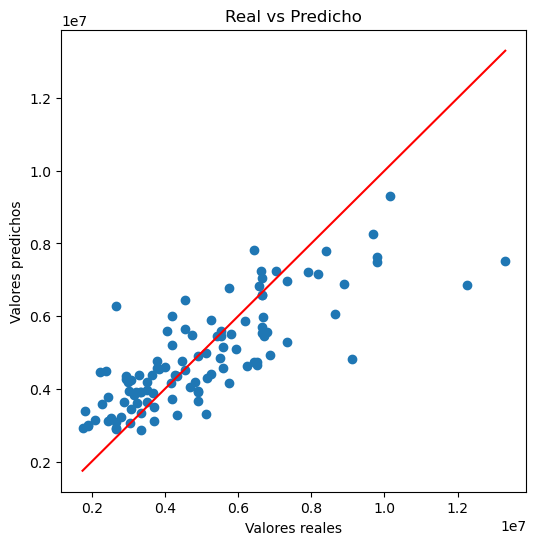

In [42]:
#comparacion entre lo real y lo predicho
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Real vs Predicho")

plt.show()

In [46]:
r2_train
r2_test
print(r2_train, r2_test)

0.6295343438678265 0.6119372009958433


### Comparación entre valores reales y predichos

Se observa una tendencia positiva entre los valores reales y los valores predichos, lo que indica que el modelo logra capturar parcialmente la relación entre las variables.

Sin embargo, existe una dispersión considerable respecto a la línea ideal, lo que sugiere que el modelo presenta limitaciones en su capacidad predictiva.

Las limitaciones del modelo pueden deberse a la simplicidad de la regresión lineal utilizada, la presencia de valores atípicos o a que las relaciones entre variables no sean completamente lineales.

En este sentido, podría ser útil explorar modelos más complejos que capturen relaciones no lineales.